In [45]:
!pip install imbalanced-learn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

In [46]:
fraud_df = pd.read_csv('/content/synthetic_fraud_dataset.csv')
fraud_df

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0
...,...,...,...,...,...,...,...,...,...,...
9995,1076,482,58.366442,POS,Clothing,DE,12,0.066366,0.086344,0
9996,4995,904,139.502160,POS,Travel,DE,13,0.119014,0.285680,0
9997,3485,527,71.012122,Online,Travel,TR,8,0.119204,0.262262,0
9998,7922,771,21.031405,QR,Grocery,UK,12,0.027088,0.295243,0


In [47]:
fraud_df.columns

Index(['transaction_id', 'user_id', 'amount', 'transaction_type',
       'merchant_category', 'country', 'hour', 'device_risk_score',
       'ip_risk_score', 'is_fraud'],
      dtype='object')

In [48]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [49]:
fraud_df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [50]:
fraud_df.size

100000

In [51]:
fraud_df.shape

(10000, 10)

In [52]:
fraud_df.isnull().sum()

,0
transaction_id,0
user_id,0
amount,0
transaction_type,0
merchant_category,0
country,0
hour,0
device_risk_score,0
ip_risk_score,0
is_fraud,0


## **Converting Categorical Columns into Numbers**

### **1) Transaction Type**

In [53]:
fraud_df['transaction_type'].unique()

array(['ATM', 'QR', 'Online', 'POS'], dtype=object)

In [54]:
fraud_df['transaction_type'] = fraud_df['transaction_type'].map({'ATM':0, 'QR':1, 'Online':2, 'POS':3})

### **2) Merchant Category**

In [55]:
fraud_df['merchant_category'].unique()

array(['Travel', 'Food', 'Clothing', 'Grocery', 'Electronics'],
      dtype=object)

In [56]:
fraud_df['merchant_category'] = fraud_df['merchant_category'].map({'Travel':0, 'Food': 1, 'Clothing': 2, 'Grocery':3, 'Electronics': 4})

### **3) Country**

In [57]:
fraud_df['country'].unique()

array(['TR', 'US', 'FR', 'DE', 'UK', 'NG'], dtype=object)

In [58]:
fraud_df['country'] = fraud_df['country'].map({'TR':0, 'US': 1, 'FR': 2, 'DE':3, 'UK': 4, 'NG':5})

### **Updated DataSet**

In [59]:
fraud_df

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,0,0,0,12,0.992347,0.947908,1
1,456,692,48.018303,1,1,1,21,0.168571,0.224057,0
2,4747,587,136.881960,2,0,0,14,0.296127,0.125058,0
3,6934,445,80.534719,3,2,0,23,0.124801,0.159243,0
4,1646,729,120.041158,2,3,2,16,0.098129,0.027542,0
...,...,...,...,...,...,...,...,...,...,...
9995,1076,482,58.366442,3,2,3,12,0.066366,0.086344,0
9996,4995,904,139.502160,3,0,3,13,0.119014,0.285680,0
9997,3485,527,71.012122,2,0,0,8,0.119204,0.262262,0
9998,7922,771,21.031405,1,3,4,12,0.027088,0.295243,0


## **Selecting only the useful columns**

In [60]:
fraud_df = fraud_df[['amount', 'transaction_type', 'merchant_category', 'hour', 'country', 'is_fraud']]

In [61]:
fraud_df.columns

Index(['amount', 'transaction_type', 'merchant_category', 'hour', 'country',
       'is_fraud'],
      dtype='object')

In [62]:
fraud_df.isnull().sum()

,0
amount,0
transaction_type,0
merchant_category,0
hour,0
country,0
is_fraud,0


## **Split Features (X) and Label (y)**

In [63]:
X = fraud_df.drop("is_fraud", axis=1)
y = fraud_df["is_fraud"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [65]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


## **Logistic Regression**

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [67]:
lg = LogisticRegression(max_iter=2000)
lg

LogisticRegression(max_iter=2000)

In [68]:
lg.fit(X_train_scaled, y_train_sm)

LogisticRegression(max_iter=2000)

In [69]:
y_pred_lg = lg.predict(X_test_scaled)
y_pred_lg

array([0, 0, 0, ..., 0, 0, 0])

In [70]:
print("Training Score:", lg.score(X_train_scaled, y_train_sm))
print("Testing Score:", lg.score(X_test_scaled, y_test))

Training Score: 0.8626315789473684
Testing Score: 0.911


In [71]:
print('Classification Report: \n', classification_report(y_test, y_pred_lg))

Classification Report: 
               precision    recall  f1-score   support

           0       0.99      0.92      0.95      1900
           1       0.34      0.82      0.48       100

    accuracy                           0.91      2000
   macro avg       0.66      0.87      0.72      2000
weighted avg       0.96      0.91      0.93      2000



In [72]:
cm_lg = confusion_matrix(y_test, y_pred_lg)
print('Confusion Matrix: \n', cm_lg)

Confusion Matrix: 
 [[1740  160]
 [  18   82]]


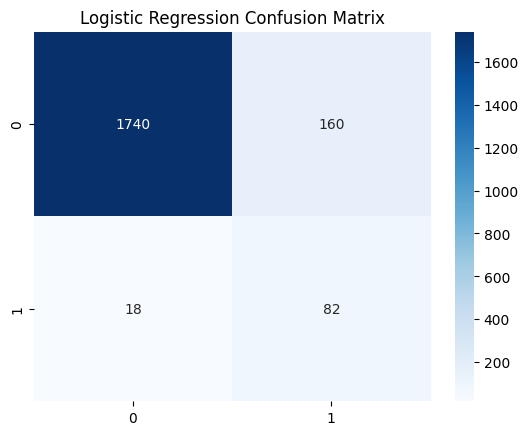

In [73]:
sns.heatmap(cm_lg, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [74]:
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lg))
print("Precision:", precision_score(y_test, y_pred_lg))
print("Recall:", recall_score(y_test, y_pred_lg))
print("F1 Score:", f1_score(y_test, y_pred_lg))

Logistic Regression Metrics:
Accuracy: 0.911
Precision: 0.33884297520661155
Recall: 0.82
F1 Score: 0.47953216374269003


## **Random Forest Classifier**

In [75]:
rf = RandomForestClassifier(random_state=42)
rf

RandomForestClassifier(random_state=42)

In [76]:
rf.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [77]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0])

In [78]:
print("Training Score: ", rf.score(X_train_sm, y_train_sm))
print("Testing Score: ", rf.score(X_test, y_test))

Training Score:  1.0
Testing Score:  0.9965


In [79]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       0.96      0.97      0.97       100

    accuracy                           1.00      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [80]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

Confusion Matrix:
 [[1896    4]
 [   3   97]]


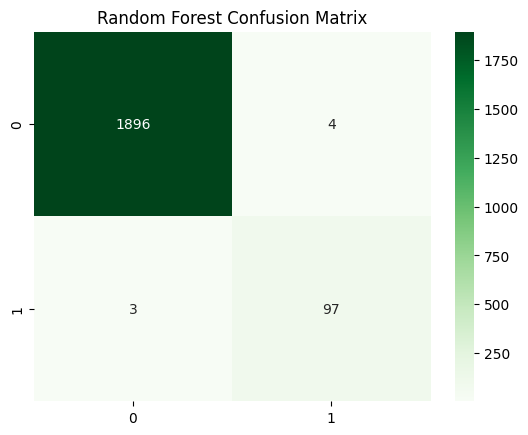

In [81]:
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [82]:
print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Metrics:
Accuracy: 0.9965
Precision: 0.9603960396039604
Recall: 0.97
F1 Score: 0.9651741293532339


## **Comparison Table**

In [83]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lg),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lg),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lg),
        f1_score(y_test, y_pred_rf)
    ]
})

results


,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.338843,0.82,0.479532
1,Random Forest,0.960396,0.97,0.965174


## **Comparison Bar Chart**

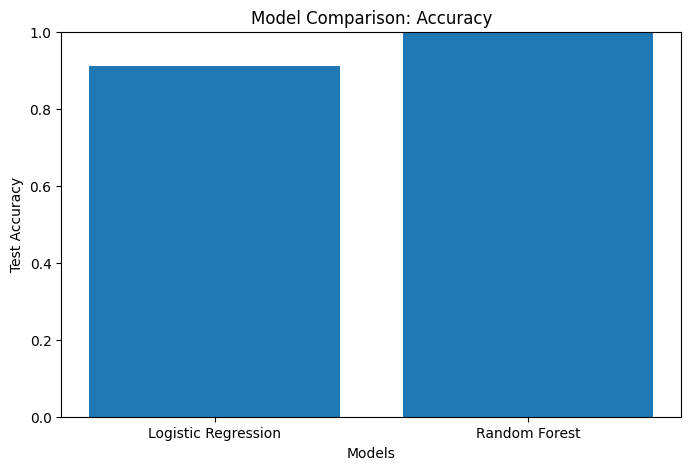

In [84]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
accuracies = [accuracy_score(y_test, y_pred_lg), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Test Accuracy")
plt.title("Model Comparison: Accuracy")
plt.ylim(0,1)
plt.show()

## **Feature Importance (Random Forest Only)**

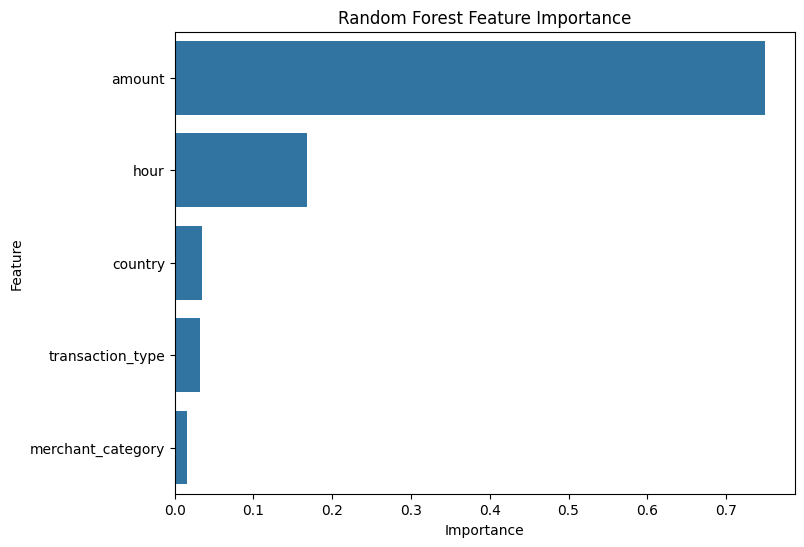

In [85]:
importances = rf.feature_importances_
feat_names = X.columns

feat_imp = pd.DataFrame({"Feature": feat_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Random Forest Feature Importance")
plt.show()


In [86]:
# Logistic Regression metrics
prec_lg = precision_score(y_test, y_pred_lg)
rec_lg = recall_score(y_test, y_pred_lg)
f1_lg = f1_score(y_test, y_pred_lg)

# Random Forest metrics
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

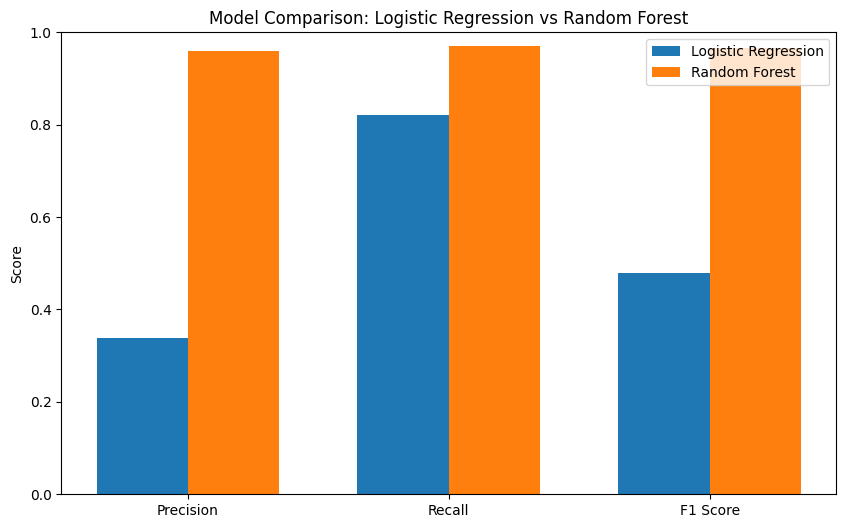

In [87]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1 Score"]
lg_scores = [prec_lg, rec_lg, f1_lg]
rf_scores = [prec_rf, rec_rf, f1_rf]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, lg_scores, width, label='Logistic Regression')
plt.bar(x + width/2, rf_scores, width, label='Random Forest')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison: Logistic Regression vs Random Forest")
plt.legend()
plt.ylim(0, 1)

plt.show()
